# Block Blast AI — Notebook tổng hợp hệ thống

## Giới thiệu tổng quan

Notebook này xây dựng một hệ thống AI cho game **Block Blast** (biến thể giới hạn Tetriminos trên bàn 8×8).  
Mỗi lượt chơi, người chơi nhận 3–4 khối hình và phải đặt tất cả lên bàn. Mục tiêu là xóa được nhiều hàng/cột nhất có thể.

### 5 thành phần

| # | Thành phần | Phương pháp sử dụng |
|---|-----------|---------------------|
| A | Biểu diễn & Tìm kiếm | State/Action/Goal/Cost + Best-first Search |
| B | Heuristic hoặc CSP | Hàm heuristic 3 thành phần (holes, area, lines) |
| C | Biểu diễn & Suy luận tri thức | IF-THEN rules mã hóa chiến thuật đặt block |
| D | Mạng Bayes / Xác suất | Bayes |
| E | Học máy | Decision Tree phân loại nước đi tốt/xấu |

import numpy as np
import heapq
from itertools import count

In [ ]:
import numpy as np
import heapq
from itertools import count

## Section 1 — Định nghĩa khối hình (Tetriminos)

Block Blast sử dụng 7 khối Tetrimino cổ điển (O, I, S, Z, L, J, T).  
Mỗi khối có thể xoay 0°/90°/180°/270°, tạo ra ~25 biến thể.  
Ta biểu diễn mỗi biến thể bằng ma trận nhị phân `numpy` (1 = ô có khối, 0 = ô trống).

**Ví dụ khối T xoay 180°:**
```
[[1, 1, 1],
 [0, 1, 0]]
```

In [ ]:
# Dase Block
base = {
    'O': np.array([[1, 1],
                   [1, 1]]),
    'I': np.array([[1, 1, 1, 1]]),
    'S': np.array([[0, 1, 1],
                   [1, 1, 0]]),
    'Z': np.array([[1, 1, 0],
                   [0, 1, 1]]),
    'L': np.array([[0, 0, 1],
                   [1, 1, 1]]),
    'J': np.array([[1, 0, 0],
                   [1, 1, 1]]),
    'T': np.array([[0, 1, 0],
                   [1, 1, 1]])
}

# Rotate Base
TETRIMINOS = {
    'O': base['O'],

    'I_0': base['I'],
    'I_90': np.rot90(base['I']),

    'S_0': base['S'],
    'S_90': np.rot90(base['S']),
    'S_180': np.rot90(base['S'], 2),
    'S_270': np.rot90(base['S'], 3),

    'Z_0': base['Z'],
    'Z_90': np.rot90(base['Z']),
    'Z_180': np.rot90(base['Z'], 2),
    'Z_270': np.rot90(base['Z'], 3),

    'L_0': base['L'],
    'L_90': np.rot90(base['L']),
    'L_180': np.rot90(base['L'], 2),
    'L_270': np.rot90(base['L'], 3),

    'J_0': base['J'],
    'J_90': np.rot90(base['J']),
    'J_180': np.rot90(base['J'], 2),
    'J_270': np.rot90(base['J'], 3),

    'T_0': base['T'],
    'T_90': np.rot90(base['T']),
    'T_180': np.rot90(base['T'], 2),
    'T_270': np.rot90(base['T'], 3),
}

---
## Section 2 — Module A: Biểu diễn bài toán & Tìm kiếm

Đây là backbone của toàn bộ hệ thống. Ta mô hình hóa game thành bài toán tìm kiếm cổ điển:

| Khái niệm | Ý nghĩa trong Block Blast |
|-----------|--------------------------|
| **State** | Trạng thái bàn 8×8 + danh sách khối còn lại + điểm hiện tại |
| **Action** | Đặt khối `block_name` tại tọa độ `(x, y)` |
| **Goal** | Đặt xong toàn bộ khối trong lượt (available_blocks = []) |
| **Cost** | Hàm phạt dựa trên: số vùng trống mới tạo ra, diện tích bounding box tăng, số dòng xóa được |

### Luồng dữ liệu
```
board (8×8) + available_blocks
        │
        ▼
   State object
        │
        ├── get_valid_actions() → list[(block_name, x, y)]
        ├── can_place(block, x, y) → bool
        └── place_block(block, x, y) → State mới
```


### 2.1 — Hàm tiện ích xử lý bàn cờ

Các hàm dưới đây được dùng bởi cả `State` lẫn hàm heuristic:

- `clear_full_lines()` — xóa hàng/cột đầy, trả về số ô đã xóa  
- `get_empty_components()` — tìm các vùng trống liên thông (flood-fill)  
- `count_empty_components()` — đếm số vùng trống (dùng trong heuristic)  
- `bounding_box_area()` — tính diện tích hình chữ nhật bao quanh toàn bộ ô đang chiếm  
- `apply_block_and_clear()` — đặt block + xóa dòng đầy, trả về dict thông tin


In [ ]:
def clear_full_lines(board):
    """
    Clear every fully occupied row and column using Numpy Vectorization.
    """
    full_rows = np.where(board.all(axis=1))[0].tolist()
    full_cols = np.where(board.all(axis=0))[0].tolist()

    new_board = np.copy(board)

    # Gán trực tiếp giá trị 0 theo mảng chỉ mục
    if full_rows:
        new_board[full_rows, :] = 0
    if full_cols:
        new_board[:, full_cols] = 0

    # Tính số ô đã xóa bằng hiệu của tổng ma trận trước và sau khi clear
    cleared_cells = int(board.sum() - new_board.sum())

    return new_board, cleared_cells, full_rows, full_cols


def get_empty_components(board):
    """
    Groups connected empty spaces (4 directional) together
    and checks if they are trapped or touch the board's edges

    Returns:
        components: list of lists of cells
    """
    H, W = board.shape
    visited = np.zeros((H, W), dtype=bool)
    components = []
    directions = [(-1, 0), (1, 0), (0, -1), (0, 1)]

    for x in range(H):
        for y in range(W):
            if board[x, y] != 0 or visited[x, y]:
                continue

            stack = [(x, y)]
            visited[x, y] = True
            cells = []

            while stack:
                cx, cy = stack.pop()
                cells.append((cx, cy))

                for dx, dy in directions:
                    nx, ny = cx + dx, cy + dy
                    if 0 <= nx < H and 0 <= ny < W:
                        if board[nx, ny] == 0 and not visited[nx, ny]:
                            visited[nx, ny] = True
                            stack.append((nx, ny))

            components.append(cells)

    return components


def count_empty_components(board):
    """
    Returns the number of connected empty components
    """
    return len(get_empty_components(board))


def bounding_box_area(board):
    """
    Returns the area of the smallest rectangle covering all occupied cells
    """
    occupied = np.argwhere(board == 1)

    if len(occupied) == 0:
        return 0

    min_x, min_y = occupied.min(axis=0)
    max_x, max_y = occupied.max(axis=0)

    return (max_x - min_x + 1) * (max_y - min_y + 1)


def apply_block_and_clear(board, block_name, x, y):

    block = TETRIMINOS[block_name]
    h, w = block.shape

    board_after_place = np.copy(board)
    placed_cells = []

    for i in range(h):
        for j in range(w):
            if block[i, j] == 1:
                board_after_place[x + i, y + j] = 1
                placed_cells.append((x + i, y + j))

    board_after_clear, cleared_cells, full_rows, full_cols = clear_full_lines(board_after_place)

    return {
        "board_after_place": board_after_place,
        "board_after_clear": board_after_clear,
        "placed_cells": placed_cells,
        "cleared_cells": cleared_cells,
        "full_rows": full_rows,
        "full_cols": full_cols,
        "lines_cleared": len(full_rows) + len(full_cols)
    }

### 2.2 — Class `State` và `Node`

`State` lưu toàn bộ thông tin 1 snapshot của game.


- init(): Khởi tạo bàn 8x8, danh sách các block cần đặt và điểm
- is_goal(): Kiểm tra danh sách `available_blocks` đã hết chưa
- key(): Tạo một ID riêng cho mỗi `state` để giúp mô hình nhận diện và so sánh
- can_place(): kiểm tra xem một block có thể đặt vào một vị trí `(x,y)` trên bàn không
- get_valid_actions(): quét hết bàn và liệt kê mọi vị trí có thể đặt block
- is_terminal(): Kiểm tra xem trò chơi dừng chưa (có thể là do hết blocks cần đặt hoặc do hết nước đi hợp lệ)
- place_block(): Hiện thực việc đặt block

`Node` bọc `State` lại để dùng trong cây tìm kiếm (lưu parent, action đã dẫn đến node này, path cost).


In [ ]:
class State:
    def __init__(self, board, available_blocks, current_score=0):
        """
        State for one-turn search.

        Args:
            board: 8x8 numpy array
            available_blocks: list of remaining blocks in the current turn
            current_score: accumulated score in this turn
        """
        self.board = np.copy(board)
        self.available_blocks = list(available_blocks)
        self.current_score = current_score

    def is_goal(self):
        return len(self.available_blocks) == 0

    def key(self):
        """
        Hashable state representation.
        """
        return (
            tuple(self.board.flatten()),
            tuple(sorted(self.available_blocks))
        )

    def can_place(self, block_name, x, y):
        if block_name not in TETRIMINOS:
            return False

        block = TETRIMINOS[block_name]
        h, w = block.shape
        H, W = self.board.shape

        if x < 0 or y < 0 or x + h > H or y + w > W:
            return False

        for i in range(h):
            for j in range(w):
                if block[i, j] == 1 and self.board[x + i, y + j] == 1:
                    return False

        return True

    def get_valid_actions(self):
        actions = []
        H, W = self.board.shape

        for block_name in sorted(set(self.available_blocks)):
            block = TETRIMINOS[block_name]
            h, w = block.shape

            for x in range(H - h + 1):
                for y in range(W - w + 1):
                    if self.can_place(block_name, x, y):
                        actions.append((block_name, x, y))

        return actions

    def is_terminal(self):
        return self.is_goal() or len(self.get_valid_actions()) == 0

    def place_block(self, block_name, x, y, return_info=False):
        if block_name not in self.available_blocks:
            return (None, None) if return_info else None

        if not self.can_place(block_name, x, y):
            return (None, None) if return_info else None

        info = apply_block_and_clear(self.board, block_name, x, y)

        new_blocks = list(self.available_blocks)
        new_blocks.remove(block_name)

        new_state = State(
            board=info["board_after_clear"],
            available_blocks=new_blocks,
            current_score=self.current_score + info["cleared_cells"]
        )

        if return_info:
            return new_state, info
        return new_state

    def __repr__(self):
        return f"State(score={self.current_score}, remaining_blocks={self.available_blocks})"


class Node:
    def __init__(self, state, parent=None, action=None, path_cost=0):
        self.state = state
        self.parent = parent
        self.action = action
        self.path_cost = path_cost
        self.priority = 0

        self.depth = 0
        if parent is not None:
            self.depth = parent.depth + 1

    def __lt__(self, other):
        return self.priority < other.priority

---
## Section 3 — Module B: Heuristic & Best-first Search

Đây là "bộ não" ra quyết định. Thay vì duyệt cạn tất cả trạng thái (quá chậm),  
ta dùng **hàm heuristic** để ưu tiên khám phá các nước đi có vẻ tốt hơn.

### Hàm chi phí chuyển trạng thái (Transition Cost)

$$\text{Cost}(s, a, s') = w_1 \cdot \Delta\text{Holes} + w_2 \cdot \Delta\text{Area} - w_3 \cdot \Delta\text{LinesCleared} + K$$

| Thành phần | Ý nghĩa | Trọng số mặc định |
|------------|---------|-------------------|
| $\Delta\text{Holes}$ | Tăng số vùng trống bị cô lập → **xấu** | $w_1 = 4$ |
| $\Delta\text{Area}$ | Tăng diện tích bounding box → **lãng phí không gian** | $w_2 = 2$ |
| $\Delta\text{LinesCleared}$ | Xóa được hàng/cột → **tốt** (trừ đi) | $w_3 = 6$ |
| $K$ | Hằng số để cost luôn dương | $K = 8$ |

### Hàm đánh giá node

$$\text{Eval}(n) = g(n) + \lambda \cdot |\text{Blocks còn lại}|$$

- $g(n)$: tổng cost tích lũy từ root đến node $n$  
- $\lambda$: trọng số phạt cho mỗi block chưa đặt được (mặc định = 5)

Node có `Eval` **thấp hơn** được ưu tiên khám phá trước.


In [ ]:
def transition_cost(prev_state, action, next_state, w1=4, w2=2, w3=6, K=8):
    """
    Weighted penalty function:
        Cost = w1 * DeltaHoles + w2 * DeltaArea - w3 * DeltaLinesCleared + K
    """
    prev_holes = count_empty_components(prev_state.board)
    next_holes = count_empty_components(next_state.board)
    delta_holes = next_holes - prev_holes

    prev_area = bounding_box_area(prev_state.board)
    next_area = bounding_box_area(next_state.board)
    delta_area = next_area - prev_area

    _, info = prev_state.place_block(*action, return_info=True)
    delta_lines_cleared = info["lines_cleared"] if info is not None else 0

    cost = (
        w1 * delta_holes
        + w2 * delta_area
        - w3 * delta_lines_cleared
        + K
    )

    return max(0, cost)


def evaluate_node(node, remaining_weight=5):
    """
    Eval(n) = g(n) + remaining_weight * |remaining_blocks(n)|
    """
    return node.path_cost + remaining_weight * len(node.state.available_blocks)


def reconstruct_path(node):
    """
    """
    actions = []
    current = node

    while current is not None and current.action is not None:
        actions.append(current.action)
        current = current.parent

    actions.reverse()
    return actions


def reconstruct_node_chain(node):
    chain = []
    current = node

    while current is not None:
        chain.append(current)
        current = current.parent

    chain.reverse()
    return chain


def print_solution(result):
    node, expansions, found_terminal = result

    if node is None:
        print("No solution found.")
        return

    actions = reconstruct_path(node)

    print("Expanded nodes:", expansions)
    print("Terminal found:", found_terminal)
    print("Best score:", node.state.current_score)
    print("Placed blocks:", len(actions))
    print("Remaining blocks:", node.state.available_blocks)

    print("\nAction sequence:")
    for step, action in enumerate(actions, start=1):
        print(f"  Step {step}: place {action[0]} at ({action[1]}, {action[2]})")

    print("\nFinal board:")
    print(node.state.board)

# Section 4- Module C Biểu diễn và suy luận tri thức

Phần này hiện thực hóa các vị từ logic được mô tả trong báo cáo và **tích hợp trực tiếp**
vào hàm `best_first_search` ở cell tiếp theo (không còn là biến thể riêng):

- **Vị từ nền tảng**: `Empty`, `Remain`, `Placeable`, `Covers`, `Line`.
- **Vị từ suy diễn**: `OneAway`, `Fillable`, `Trapped`, `Completes`.

Hai vị từ suy diễn được tích hợp như sau:

1. `Trapped(i,j,s)` — đánh giá trên `board_after_clear` — dùng để cắt nhánh sớm các
   trạng thái có ô trống không thể được lấp bởi bất kỳ khối còn lại nào.
2. `Completes(b,x,y,s)` — dùng để giảm priority (cộng bonus) cho action có khả năng
   hoàn tất một hàng hoặc cột gần đầy.

`Fillable` được tính một lần trên mỗi state thông qua một *coverage mask* duy nhất.

Các tham số `prune_trapped` và `completion_bonus` của `best_first_search` cho phép
bật/tắt lớp tri thức khi chạy ablation.

**Lưu ý thứ tự định nghĩa**: cell helper KR phải được định nghĩa *trước* `best_first_search`
vì hàm này tham chiếu trực tiếp đến `has_trapped_cell` và `action_completes_line`.

In [ ]:
# === Knowledge representation: derived predicates ===

def compute_coverage_mask(state):
    """
    Build a board-shaped boolean mask where mask[i,j] is True iff there exists
    some (b, x, y) with Remain(b,s) AND Placeable(b,x,y,s) AND Covers(b,x,y,i,j).

    This realizes the Fillable predicate as a single sweep per state:
        Fillable(i,j,s)  <=>  coverage_mask[i,j]
    """
    H, W = state.board.shape
    mask = np.zeros((H, W), dtype=bool)

    for block_name in set(state.available_blocks):
        block = TETRIMINOS[block_name]
        h, w = block.shape

        for x in range(H - h + 1):
            for y in range(W - w + 1):
                if not state.can_place(block_name, x, y):
                    continue
                for i in range(h):
                    for j in range(w):
                        if block[i, j] == 1:
                            mask[x + i, y + j] = True

    return mask


def has_trapped_cell(state):
    """
    Trapped(i,j,s)  <=>  Empty(i,j,s) AND NOT Fillable(i,j,s)

    Evaluated on state.board, which after a place_block call is already
    board_after_clear (place_block runs apply_block_and_clear internally).
    Returns False for the goal state since Trapped only matters while there
    are still blocks to place this turn.
    """
    if len(state.available_blocks) == 0:
        return False

    coverage = compute_coverage_mask(state)
    empty = (state.board == 0)
    trapped = empty & ~coverage
    return bool(trapped.any())


def action_completes_line(state, action):
    """
    Completes(b,x,y,s)  <=>  there exists a line ell and cell (i,j) such that
        OneAway(ell, s) AND (i,j) in ell AND Empty(i,j,s) AND Covers(b,x,y,i,j)

    A row/column is OneAway iff it has exactly one empty cell on the
    pre-placement board AND the action's covered cells include that empty cell.
    """
    block_name, x, y = action
    block = TETRIMINOS[block_name]
    H, W = state.board.shape
    h, w = block.shape

    covered = set()
    for i in range(h):
        for j in range(w):
            if block[i, j] == 1:
                covered.add((x + i, y + j))

    for r in range(H):
        empties = [j for j in range(W) if state.board[r, j] == 0]
        if len(empties) == 1 and (r, empties[0]) in covered:
            return True

    for c in range(W):
        empties = [i for i in range(H) if state.board[i, c] == 0]
        if len(empties) == 1 and (empties[0], c) in covered:
            return True

    return False


In [ ]:
def best_first_search(
    initial_state,
    max_expansions=5000,
    w1=4,
    w2=2,
    w3=6,
    K=8,
    remaining_weight=5,
    prune_trapped=True,
    completion_bonus=10.0,
):
    """
    Best-first Search for one-turn block placement.

    The base evaluation is
        Eval(n) = g(n) + remaining_weight * |remaining_blocks(n)|

    Two knowledge-layer integrations (Chapter 4) sit on top:
      1. prune_trapped:    skip children where any cell satisfies
                           Trapped(i,j,s) on the post-clear board.
      2. completion_bonus: subtract this constant from priority when an
                           action satisfies Completes(b,x,y,s).

    Set prune_trapped=False and completion_bonus=0.0 for an ablation run
    that disables the knowledge layer entirely.

    Returns:
        best_terminal or best_partial,
        expansions,
        found_terminal
    """
    from itertools import count as _count
    root = Node(initial_state)
    root.priority = evaluate_node(root, remaining_weight=remaining_weight)

    frontier = []
    counter = _count()
    heapq.heappush(frontier, (root.priority, next(counter), root))

    best_seen_score = {initial_state.key(): initial_state.current_score}

    best_terminal = None
    best_partial = root
    expansions = 0

    while frontier and expansions < max_expansions:
        _, _, node = heapq.heappop(frontier)
        state = node.state
        key = state.key()

        if state.current_score < best_seen_score.get(key, -1):
            continue

        if node.state.current_score > best_partial.state.current_score:
            best_partial = node
        elif node.state.current_score == best_partial.state.current_score:
            if len(node.state.available_blocks) < len(best_partial.state.available_blocks):
                best_partial = node

        if state.is_terminal():
            if best_terminal is None or state.current_score > best_terminal.state.current_score:
                best_terminal = node
            continue

        expansions += 1

        for action in state.get_valid_actions():
            child_state = state.place_block(*action)
            if child_state is None:
                continue

            child_key = child_state.key()

            if child_state.current_score <= best_seen_score.get(child_key, -1):
                continue

            if prune_trapped and has_trapped_cell(child_state):
                continue

            step_cost = transition_cost(
                state, action, child_state,
                w1=w1, w2=w2, w3=w3, K=K
            )

            child = Node(
                state=child_state,
                parent=node,
                action=action,
                path_cost=node.path_cost + step_cost
            )

            base_eval = evaluate_node(child, remaining_weight=remaining_weight)
            if completion_bonus > 0 and action_completes_line(state, action):
                child.priority = base_eval - completion_bonus
            else:
                child.priority = base_eval

            best_seen_score[child_key] = child_state.current_score
            heapq.heappush(frontier, (child.priority, next(counter), child))

    if best_terminal is not None:
        return best_terminal, expansions, True
    else:
        return best_partial, expansions, False


# Section 5 - Bayes Risk Estimation Experiment

Module Bayes độc lập để sinh dữ liệu mô phỏng, học CPD bằng frequency count và suy diễn xác suất `StuckRisk`.

Biến dùng trong mô hình: `Density`, `Fragmentation`, `LineClear`, `ValidMoveLevel`, `StuckRisk`.

In [ ]:
# Independent Bayes Risk Estimation module for Chapter 5.
# This cell intentionally defines only BAYES_/bayes_ utilities so it does not
# override the global game/search/heuristic/Decision Tree functions.

import os
from itertools import product

import numpy as np
import pandas as pd


BAYES_BOARD_SIZE = 8
BAYES_DEFAULT_N_SAMPLES = 50_000
BAYES_DEFAULT_BLOCKS_PER_TURN = 4
BAYES_DEFAULT_ROLLOUT_HORIZON_TURNS = 3
BAYES_DEFAULT_MIN_COUNT = 30


# -----------------------------------------------------------------------------
# A. Local game utilities for the Bayes experiment only
# -----------------------------------------------------------------------------

BAYES_BASE_BLOCKS = {
    'O': np.array([[1, 1],
                   [1, 1]], dtype=int),
    'I': np.array([[1, 1, 1, 1]], dtype=int),
    'S': np.array([[0, 1, 1],
                   [1, 1, 0]], dtype=int),
    'Z': np.array([[1, 1, 0],
                   [0, 1, 1]], dtype=int),
    'L': np.array([[0, 0, 1],
                   [1, 1, 1]], dtype=int),
    'J': np.array([[1, 0, 0],
                   [1, 1, 1]], dtype=int),
    'T': np.array([[0, 1, 0],
                   [1, 1, 1]], dtype=int),
}

BAYES_TETRIMINOS = {
    'O': BAYES_BASE_BLOCKS['O'],
    'I_0': BAYES_BASE_BLOCKS['I'],
    'I_90': np.rot90(BAYES_BASE_BLOCKS['I']),
    'S_0': BAYES_BASE_BLOCKS['S'],
    'S_90': np.rot90(BAYES_BASE_BLOCKS['S']),
    'S_180': np.rot90(BAYES_BASE_BLOCKS['S'], 2),
    'S_270': np.rot90(BAYES_BASE_BLOCKS['S'], 3),
    'Z_0': BAYES_BASE_BLOCKS['Z'],
    'Z_90': np.rot90(BAYES_BASE_BLOCKS['Z']),
    'Z_180': np.rot90(BAYES_BASE_BLOCKS['Z'], 2),
    'Z_270': np.rot90(BAYES_BASE_BLOCKS['Z'], 3),
    'L_0': BAYES_BASE_BLOCKS['L'],
    'L_90': np.rot90(BAYES_BASE_BLOCKS['L']),
    'L_180': np.rot90(BAYES_BASE_BLOCKS['L'], 2),
    'L_270': np.rot90(BAYES_BASE_BLOCKS['L'], 3),
    'J_0': BAYES_BASE_BLOCKS['J'],
    'J_90': np.rot90(BAYES_BASE_BLOCKS['J']),
    'J_180': np.rot90(BAYES_BASE_BLOCKS['J'], 2),
    'J_270': np.rot90(BAYES_BASE_BLOCKS['J'], 3),
    'T_0': BAYES_BASE_BLOCKS['T'],
    'T_90': np.rot90(BAYES_BASE_BLOCKS['T']),
    'T_180': np.rot90(BAYES_BASE_BLOCKS['T'], 2),
    'T_270': np.rot90(BAYES_BASE_BLOCKS['T'], 3),
}

BAYES_STATES = {
    'Density': ['Low', 'Medium', 'High'],
    'Fragmentation': ['Low', 'Medium', 'High'],
    'LineClear': ['No', 'Yes'],
    'ValidMoveLevel': ['Low', 'Medium', 'High'],
    'StuckRisk': ['Low', 'Medium', 'High'],
}


def bayes_clear_full_lines(board):
    board = np.asarray(board, dtype=int)
    full_rows = np.where(board.all(axis=1))[0].tolist()
    full_cols = np.where(board.all(axis=0))[0].tolist()

    new_board = np.copy(board)
    if full_rows:
        new_board[full_rows, :] = 0
    if full_cols:
        new_board[:, full_cols] = 0

    cleared_cells = int(board.sum() - new_board.sum())
    return new_board, cleared_cells, full_rows, full_cols


def bayes_can_place(board, block_name, x, y):
    if block_name not in BAYES_TETRIMINOS:
        return False

    board = np.asarray(board, dtype=int)
    block = BAYES_TETRIMINOS[block_name]
    h, w = block.shape
    H, W = board.shape

    if x < 0 or y < 0 or x + h > H or y + w > W:
        return False

    target = board[x:x + h, y:y + w]
    return bool(np.all((block == 0) | (target == 0)))


def bayes_get_valid_actions(board, available_blocks):
    board = np.asarray(board, dtype=int)
    H, W = board.shape
    actions = []

    for block_name in sorted(set(available_blocks)):
        if block_name not in BAYES_TETRIMINOS:
            continue
        block = BAYES_TETRIMINOS[block_name]
        h, w = block.shape
        for x in range(H - h + 1):
            for y in range(W - w + 1):
                if bayes_can_place(board, block_name, x, y):
                    actions.append((block_name, x, y))

    return actions


def bayes_has_valid_action_for_block(board, block_name):
    if block_name not in BAYES_TETRIMINOS:
        return False

    board = np.asarray(board, dtype=int)
    H, W = board.shape
    block = BAYES_TETRIMINOS[block_name]
    h, w = block.shape

    for x in range(H - h + 1):
        for y in range(W - w + 1):
            if bayes_can_place(board, block_name, x, y):
                return True
    return False


def bayes_count_placeable_remaining_blocks(board, remaining_blocks):
    return sum(
        1
        for block_name in set(remaining_blocks)
        if bayes_has_valid_action_for_block(board, block_name)
    )


def bayes_place_block_and_clear(board, block_name, x, y):
    if not bayes_can_place(board, block_name, x, y):
        raise ValueError(f'Invalid Bayes action: block={block_name}, x={x}, y={y}')

    board = np.asarray(board, dtype=int)
    block = BAYES_TETRIMINOS[block_name]
    h, w = block.shape

    board_after_place = np.copy(board)
    patch = board_after_place[x:x + h, y:y + w]
    patch[block == 1] = 1
    board_after_place[x:x + h, y:y + w] = patch

    board_after_clear, cleared_cells, full_rows, full_cols = bayes_clear_full_lines(board_after_place)
    info = {
        'board_after_place': board_after_place,
        'board_after_clear': board_after_clear,
        'cleared_cells': cleared_cells,
        'full_rows': full_rows,
        'full_cols': full_cols,
        'lines_cleared': len(full_rows) + len(full_cols),
    }
    return board_after_clear, info


def bayes_count_empty_components(board):
    board = np.asarray(board, dtype=int)
    H, W = board.shape
    visited = np.zeros((H, W), dtype=bool)
    components = 0
    directions = [(-1, 0), (1, 0), (0, -1), (0, 1)]

    for x in range(H):
        for y in range(W):
            if board[x, y] != 0 or visited[x, y]:
                continue

            components += 1
            stack = [(x, y)]
            visited[x, y] = True

            while stack:
                cx, cy = stack.pop()
                for dx, dy in directions:
                    nx, ny = cx + dx, cy + dy
                    if 0 <= nx < H and 0 <= ny < W:
                        if board[nx, ny] == 0 and not visited[nx, ny]:
                            visited[nx, ny] = True
                            stack.append((nx, ny))

    return components


def bayes_filled_ratio(board):
    board = np.asarray(board, dtype=int)
    if board.size == 0:
        return 0.0
    return float(board.sum() / board.size)


def bayes_board_to_string(board):
    board = np.asarray(board, dtype=int)
    return '/'.join(''.join(str(int(cell)) for cell in row) for row in board)


def bayes_blocks_to_string(blocks):
    return '|'.join(str(block) for block in blocks)


def bayes_remove_one_block(blocks, block_name):
    remaining = list(blocks)
    remaining.remove(block_name)
    return remaining


# -----------------------------------------------------------------------------
# B. Simulated turns, rollout policy, and StuckRisk measurement
# -----------------------------------------------------------------------------

def bayes_sample_turn_blocks(rng, blocks_per_turn=BAYES_DEFAULT_BLOCKS_PER_TURN):
    block_names = list(BAYES_TETRIMINOS.keys())
    return [str(name) for name in rng.choice(block_names, size=int(blocks_per_turn), replace=True)]


def bayes_generate_random_board(fill_prob=None, num_random_blocks=None, rng=None, board_size=BAYES_BOARD_SIZE):
    rng = np.random.default_rng() if rng is None else rng

    if num_random_blocks is not None:
        board = np.zeros((board_size, board_size), dtype=int)
        block_names = list(BAYES_TETRIMINOS.keys())
        for _ in range(max(0, int(num_random_blocks))):
            block_name = str(block_names[int(rng.integers(len(block_names)))])
            actions = bayes_get_valid_actions(board, [block_name])
            if not actions:
                continue
            action = actions[int(rng.integers(len(actions)))]
            board, _ = bayes_place_block_and_clear(board, *action)
        return board

    if fill_prob is None:
        fill_prob = float(rng.uniform(0.05, 0.72))
    fill_prob = float(np.clip(fill_prob, 0.0, 0.92))

    board = (rng.random((board_size, board_size)) < fill_prob).astype(int)
    board, _, _, _ = bayes_clear_full_lines(board)
    return board


def bayes_random_board_for_dataset(rng):
    # Mix two generators to obtain both game-like boards and fragmented boards.
    if rng.random() < 0.60:
        fill_prob = float(rng.uniform(0.05, 0.70))
        return bayes_generate_random_board(fill_prob=fill_prob, rng=rng)

    num_random_blocks = int(rng.integers(0, 16))
    return bayes_generate_random_board(num_random_blocks=num_random_blocks, rng=rng)


def bayes_rollout_action_score(board, action, remaining_blocks_after_action):
    board_next, info = bayes_place_block_and_clear(board, *action)
    density_next = bayes_filled_ratio(board_next)
    fragmentation_next = bayes_count_empty_components(board_next)
    placeable_remaining = bayes_count_placeable_remaining_blocks(board_next, remaining_blocks_after_action)

    # Greedy/local policy: prefer line clears, preserve valid moves, reduce density,
    # and reduce fragmentation. The valid-move preservation term uses a fast
    # placeable-block count instead of search, keeping the Bayes rollout lightweight.
    score = (
        100.0 * info['lines_cleared']
        + 0.15 * info['cleared_cells']
        + 12.0 * placeable_remaining
        - 8.0 * density_next
        - 1.5 * fragmentation_next
    )
    return score, board_next, info


def bayes_select_rollout_action(board, available_blocks, rng, max_candidates=6):
    actions = bayes_get_valid_actions(board, available_blocks)
    if not actions:
        return None, None, None

    if len(actions) > max_candidates:
        candidate_indices = rng.choice(len(actions), size=int(max_candidates), replace=False)
        candidate_actions = [actions[int(idx)] for idx in candidate_indices]
    else:
        candidate_actions = actions

    best_score = -np.inf
    best_action = None
    best_board = None
    best_info = None

    for action in candidate_actions:
        next_blocks = bayes_remove_one_block(available_blocks, action[0])
        score, board_next, info = bayes_rollout_action_score(board, action, next_blocks)
        if score > best_score:
            best_score = score
            best_action = action
            best_board = board_next
            best_info = info

    return best_action, best_board, best_info


def bayes_measure_stuck_risk_by_rollout(
    board_after,
    remaining_blocks,
    rng,
    rollout_horizon_turns=BAYES_DEFAULT_ROLLOUT_HORIZON_TURNS,
    blocks_per_turn=BAYES_DEFAULT_BLOCKS_PER_TURN,
    max_policy_candidates=6,
):
    board = np.copy(np.asarray(board_after, dtype=int))
    current_turn_blocks = list(remaining_blocks)
    survival_steps = 0

    # First, the rollout must finish the remaining blocks of the current turn.
    while current_turn_blocks:
        action, board_next, _ = bayes_select_rollout_action(
            board,
            current_turn_blocks,
            rng,
            max_candidates=max_policy_candidates,
        )
        if action is None:
            return {
                'StuckRisk': 'High',
                'rollout_survival_steps': survival_steps,
                'rollout_status': 'stuck_current_turn',
                'rollout_turns_completed': 0,
            }

        board = board_next
        current_turn_blocks = bayes_remove_one_block(current_turn_blocks, action[0])
        survival_steps += 1

    # If the current turn is completed, simulate future turns up to the horizon.
    completed_future_turns = 0
    for _ in range(int(rollout_horizon_turns)):
        future_turn_blocks = bayes_sample_turn_blocks(rng, blocks_per_turn=blocks_per_turn)

        while future_turn_blocks:
            action, board_next, _ = bayes_select_rollout_action(
                board,
                future_turn_blocks,
                rng,
                max_candidates=max_policy_candidates,
            )
            if action is None:
                return {
                    'StuckRisk': 'Medium',
                    'rollout_survival_steps': survival_steps,
                    'rollout_status': 'stuck_before_horizon',
                    'rollout_turns_completed': completed_future_turns,
                }

            board = board_next
            future_turn_blocks = bayes_remove_one_block(future_turn_blocks, action[0])
            survival_steps += 1

        completed_future_turns += 1

    return {
        'StuckRisk': 'Low',
        'rollout_survival_steps': survival_steps,
        'rollout_status': 'survived_horizon',
        'rollout_turns_completed': completed_future_turns,
    }


# -----------------------------------------------------------------------------
# C. Feature discretization and dataset generation
# -----------------------------------------------------------------------------

def bayes_discretize_density(ratio):
    if ratio < 0.35:
        return 'Low'
    if ratio <= 0.65:
        return 'Medium'
    return 'High'


def bayes_discretize_fragmentation(num_components):
    if num_components <= 1:
        return 'Low'
    if num_components <= 3:
        return 'Medium'
    return 'High'


def bayes_discretize_lineclear(lines_cleared):
    return 'Yes' if lines_cleared > 0 else 'No'


def bayes_discretize_valid_move_level(num_valid_moves):
    if num_valid_moves < 10:
        return 'Low'
    if num_valid_moves < 30:
        return 'Medium'
    return 'High'


BAYES_DATASET_COLUMNS = [
    'sample_id',
    'board_before',
    'turn_blocks',
    'block_name',
    'x',
    'y',
    'remaining_blocks',
    'board_after',
    'density_raw',
    'fragmentation_raw',
    'lineclear_raw',
    'valid_moves_after_raw',
    'rollout_survival_steps',
    'rollout_status',
    'rollout_turns_completed',
    'Density',
    'Fragmentation',
    'LineClear',
    'ValidMoveLevel',
    'StuckRisk',
]


def generate_bayes_dataset(
    n_samples=BAYES_DEFAULT_N_SAMPLES,
    seed=42,
    max_attempts=None,
    rollout_horizon_turns=BAYES_DEFAULT_ROLLOUT_HORIZON_TURNS,
    blocks_per_turn=BAYES_DEFAULT_BLOCKS_PER_TURN,
):
    rng = np.random.default_rng(seed)
    rows = []
    attempts = 0
    max_attempts = max(100, int(n_samples) * 50) if max_attempts is None else int(max_attempts)

    while len(rows) < int(n_samples) and attempts < max_attempts:
        attempts += 1
        board_before = bayes_random_board_for_dataset(rng)
        turn_blocks = bayes_sample_turn_blocks(rng, blocks_per_turn=blocks_per_turn)
        actions = bayes_get_valid_actions(board_before, turn_blocks)
        if not actions:
            continue

        block_name, x, y = actions[int(rng.integers(len(actions)))]
        if block_name not in turn_blocks:
            raise AssertionError('Bayes dataset invariant failed: selected block is not in turn_blocks.')

        board_after, info = bayes_place_block_and_clear(board_before, block_name, x, y)
        remaining_blocks = bayes_remove_one_block(turn_blocks, block_name)

        density_raw = bayes_filled_ratio(board_after)
        fragmentation_raw = bayes_count_empty_components(board_after)
        lineclear_raw = int(info['lines_cleared'])

        # ValidMoveLevel is computed only from the blocks still unplaced in this turn.
        valid_moves_after_raw = len(bayes_get_valid_actions(board_after, remaining_blocks))

        rollout = bayes_measure_stuck_risk_by_rollout(
            board_after,
            remaining_blocks,
            rng,
            rollout_horizon_turns=rollout_horizon_turns,
            blocks_per_turn=blocks_per_turn,
        )

        rows.append({
            'sample_id': len(rows),
            'board_before': bayes_board_to_string(board_before),
            'turn_blocks': bayes_blocks_to_string(turn_blocks),
            'block_name': block_name,
            'x': x,
            'y': y,
            'remaining_blocks': bayes_blocks_to_string(remaining_blocks),
            'board_after': bayes_board_to_string(board_after),
            'density_raw': density_raw,
            'fragmentation_raw': fragmentation_raw,
            'lineclear_raw': lineclear_raw,
            'valid_moves_after_raw': valid_moves_after_raw,
            'rollout_survival_steps': rollout['rollout_survival_steps'],
            'rollout_status': rollout['rollout_status'],
            'rollout_turns_completed': rollout['rollout_turns_completed'],
            'Density': bayes_discretize_density(density_raw),
            'Fragmentation': bayes_discretize_fragmentation(fragmentation_raw),
            'LineClear': bayes_discretize_lineclear(lineclear_raw),
            'ValidMoveLevel': bayes_discretize_valid_move_level(valid_moves_after_raw),
            'StuckRisk': rollout['StuckRisk'],
        })

    if len(rows) < int(n_samples):
        print(f'Warning: requested {n_samples} samples, generated {len(rows)} valid samples after {attempts} attempts.')

    return pd.DataFrame(rows, columns=BAYES_DATASET_COLUMNS)


# -----------------------------------------------------------------------------
# D. CPD estimation by empirical frequency counts, no smoothing
# -----------------------------------------------------------------------------

def bayes_probability_columns(child):
    return [f'P({child}={value})' for value in BAYES_STATES[child]]


def bayes_estimate_cpd_no_smoothing(df, child, parents, min_count=BAYES_DEFAULT_MIN_COUNT):
    if child not in BAYES_STATES:
        raise ValueError(f'Unknown child variable: {child}')

    parents = list(parents)
    for parent in parents:
        if parent not in BAYES_STATES:
            raise ValueError(f'Unknown parent variable: {parent}')

    df = pd.DataFrame() if df is None else df.copy()
    child_values = BAYES_STATES[child]
    parent_combinations = list(product(*[BAYES_STATES[parent] for parent in parents])) if parents else [()]

    rows = []
    for combo in parent_combinations:
        mask = np.ones(len(df), dtype=bool)
        for parent, value in zip(parents, combo):
            if parent not in df.columns:
                mask &= False
            else:
                mask &= (df[parent].to_numpy() == value)

        subset = df.loc[mask] if len(df) > 0 else df
        counts = subset[child].value_counts().to_dict() if child in subset.columns else {}
        observed = int(sum(counts.get(value, 0) for value in child_values))

        if observed == 0:
            probabilities = [np.nan for _ in child_values]
            coverage_status = 'NotObserved'
        else:
            probabilities = [float(counts.get(value, 0) / observed) for value in child_values]
            coverage_status = 'LowCount' if observed < int(min_count) else 'Observed'

        row = {parent: value for parent, value in zip(parents, combo)}
        for child_value, count, probability in zip(child_values, [counts.get(v, 0) for v in child_values], probabilities):
            row[f'Count({child}={child_value})'] = int(count)
            row[f'P({child}={child_value})'] = probability
        row['ObservedCount'] = observed
        row['CoverageStatus'] = coverage_status
        rows.append(row)

    cpd = pd.DataFrame(rows)
    cpd.attrs['child'] = child
    cpd.attrs['parents'] = parents
    cpd.attrs['smoothing'] = False
    cpd.attrs['min_count'] = int(min_count)
    return cpd


def bayes_validate_cpd(cpd, child, atol=1e-9):
    prob_cols = bayes_probability_columns(child)
    missing_cols = [col for col in prob_cols if col not in cpd.columns]
    if missing_cols:
        raise AssertionError(f'Missing probability columns in CPD for {child}: {missing_cols}')
    if 'ObservedCount' not in cpd.columns:
        raise AssertionError(f'Missing ObservedCount column in CPD for {child}.')
    if 'CoverageStatus' not in cpd.columns:
        raise AssertionError(f'Missing CoverageStatus column in CPD for {child}.')

    observed_mask = cpd['ObservedCount'].to_numpy() > 0
    if observed_mask.any():
        row_sums = cpd.loc[observed_mask, prob_cols].sum(axis=1)
        max_error = float(np.max(np.abs(row_sums - 1.0)))
        if not np.allclose(row_sums, 1.0, atol=atol):
            raise AssertionError(f'Observed CPD rows for {child} do not sum to 1. Max error = {max_error}')
    else:
        max_error = 0.0

    not_observed_mask = cpd['ObservedCount'].to_numpy() == 0
    if not_observed_mask.any() and not cpd.loc[not_observed_mask, prob_cols].isna().all(axis=None):
        raise AssertionError(f'NotObserved CPD rows for {child} must keep probabilities as NaN.')

    print(f'CPD check passed for {child}: {len(cpd)} rows, observed rows sum to 1, max error = {max_error:.2e}')
    return True


# -----------------------------------------------------------------------------
# E. Inference helper with explicit insufficient-data handling
# -----------------------------------------------------------------------------

def bayes_find_cpd_row(cpd, conditions):
    mask = np.ones(len(cpd), dtype=bool)
    for column, value in conditions.items():
        if column not in cpd.columns:
            raise KeyError(f'Column {column} not found in CPD.')
        mask &= (cpd[column].to_numpy() == value)

    matches = cpd.loc[mask]
    if matches.empty:
        return None
    return matches.iloc[0]


def bayes_row_has_probability_data(row, child):
    if row is None:
        return False
    if int(row.get('ObservedCount', 0)) <= 0:
        return False
    return not pd.isna(row[bayes_probability_columns(child)]).any()


def bayes_infer_stuck_risk(density, fragmentation, lineclear, cpd_valid_move_level, cpd_stuck_risk):
    if density not in BAYES_STATES['Density']:
        raise ValueError(f'Invalid Density value: {density}')
    if fragmentation not in BAYES_STATES['Fragmentation']:
        raise ValueError(f'Invalid Fragmentation value: {fragmentation}')
    if lineclear not in BAYES_STATES['LineClear']:
        raise ValueError(f'Invalid LineClear value: {lineclear}')

    valid_row = bayes_find_cpd_row(
        cpd_valid_move_level,
        {'Density': density, 'Fragmentation': fragmentation, 'LineClear': lineclear},
    )
    if not bayes_row_has_probability_data(valid_row, 'ValidMoveLevel'):
        return {
            'status': 'InsufficientData',
            'reason': 'Missing CPD row for P(ValidMoveLevel | Density, Fragmentation, LineClear).',
            'probabilities': {risk: np.nan for risk in BAYES_STATES['StuckRisk']},
        }

    result = {risk: 0.0 for risk in BAYES_STATES['StuckRisk']}
    for valid_level in BAYES_STATES['ValidMoveLevel']:
        p_valid_level = float(valid_row[f'P(ValidMoveLevel={valid_level})'])
        if p_valid_level == 0.0:
            continue

        stuck_row = bayes_find_cpd_row(
            cpd_stuck_risk,
            {'ValidMoveLevel': valid_level, 'Fragmentation': fragmentation},
        )
        if not bayes_row_has_probability_data(stuck_row, 'StuckRisk'):
            return {
                'status': 'InsufficientData',
                'reason': f'Missing CPD row for P(StuckRisk | ValidMoveLevel={valid_level}, Fragmentation={fragmentation}).',
                'probabilities': {risk: np.nan for risk in BAYES_STATES['StuckRisk']},
            }

        for risk in BAYES_STATES['StuckRisk']:
            result[risk] += p_valid_level * float(stuck_row[f'P(StuckRisk={risk})'])

    total = sum(result.values())
    if total <= 0.0:
        return {
            'status': 'InsufficientData',
            'reason': 'The inferred distribution has zero total probability.',
            'probabilities': {risk: np.nan for risk in BAYES_STATES['StuckRisk']},
        }

    result = {risk: probability / total for risk, probability in result.items()}
    return {'status': 'OK', 'reason': None, 'probabilities': result}


# -----------------------------------------------------------------------------
# F. Report tables, validation, and CSV outputs
# -----------------------------------------------------------------------------

def bayes_make_stuckrisk_distribution(df):
    counts = df['StuckRisk'].value_counts().reindex(BAYES_STATES['StuckRisk'], fill_value=0)
    total = int(counts.sum())
    ratios = counts / total if total > 0 else counts.astype(float)
    return pd.DataFrame({
        'StuckRisk': counts.index,
        'Count': counts.astype(int).to_numpy(),
        'Ratio': ratios.astype(float).to_numpy(),
    })


def bayes_make_coverage_summary(cpd_map):
    rows = []
    for cpd_name, cpd in cpd_map.items():
        total = int(len(cpd))
        observed = int((cpd['ObservedCount'] > 0).sum()) if total else 0
        not_observed = int((cpd['ObservedCount'] == 0).sum()) if total else 0
        low_count = int((cpd['CoverageStatus'] == 'LowCount').sum()) if total else 0
        rows.append({
            'CPD': cpd_name,
            'TotalParentCombinations': total,
            'ObservedCombinations': observed,
            'NotObservedCombinations': not_observed,
            'CoverageRatio': float(observed / total) if total > 0 else np.nan,
            'LowCountCombinations': low_count,
        })
    return pd.DataFrame(rows)


def validate_bayes_outputs(
    df,
    cpd_valid_move_level,
    cpd_stuck_risk,
    expected_samples=None,
    output_dir=None,
    required_files=None,
    blocks_per_turn=BAYES_DEFAULT_BLOCKS_PER_TURN,
):
    if df.empty:
        raise AssertionError('Bayes dataset is empty.')

    if expected_samples is not None and len(df) != int(expected_samples):
        raise AssertionError(f'Expected {expected_samples} samples, but generated {len(df)} samples.')

    required_dataset_columns = set(BAYES_DATASET_COLUMNS)
    missing_dataset_columns = sorted(required_dataset_columns - set(df.columns))
    if missing_dataset_columns:
        raise AssertionError(f'Missing Bayes dataset columns: {missing_dataset_columns}')

    action_in_turn = df.apply(lambda row: row['block_name'] in str(row['turn_blocks']).split('|'), axis=1)
    if not bool(action_in_turn.all()):
        raise AssertionError('At least one Bayes sample has block_name not contained in turn_blocks.')

    expected_remaining_blocks = int(blocks_per_turn) - 1
    remaining_len_ok = df['remaining_blocks'].apply(lambda text: 0 if text == '' else len(str(text).split('|'))).eq(expected_remaining_blocks)
    if not bool(remaining_len_ok.all()):
        raise AssertionError('Each Bayes sample must remove exactly one block from turn_blocks.')

    smoothing_marker = 'Smoothed' + 'FromPrior'
    for cpd in (cpd_valid_move_level, cpd_stuck_risk):
        if smoothing_marker in cpd.columns:
            raise AssertionError('Smoothing marker found although Section 5 must not use smoothing.')

    bayes_validate_cpd(cpd_valid_move_level, 'ValidMoveLevel')
    bayes_validate_cpd(cpd_stuck_risk, 'StuckRisk')

    if output_dir is not None and required_files is not None:
        missing_files = [name for name in required_files if not os.path.exists(os.path.join(output_dir, name))]
        if missing_files:
            raise AssertionError(f'Missing Bayes output files: {missing_files}')

    print(f'Dataset check passed: {len(df)} rollout-based Bayes samples, no smoothing used.')
    return True


def run_bayes_experiment(
    n_samples=BAYES_DEFAULT_N_SAMPLES,
    seed=42,
    save_outputs=True,
    output_dir='outputs/bayes',
    rollout_horizon_turns=BAYES_DEFAULT_ROLLOUT_HORIZON_TURNS,
    blocks_per_turn=BAYES_DEFAULT_BLOCKS_PER_TURN,
    min_count=BAYES_DEFAULT_MIN_COUNT,
):
    print('Generating Bayes rollout simulation dataset...')
    df = generate_bayes_dataset(
        n_samples=n_samples,
        seed=seed,
        rollout_horizon_turns=rollout_horizon_turns,
        blocks_per_turn=blocks_per_turn,
    )

    cpd_valid_move_level = bayes_estimate_cpd_no_smoothing(
        df,
        child='ValidMoveLevel',
        parents=['Density', 'Fragmentation', 'LineClear'],
        min_count=min_count,
    )
    cpd_stuck_risk = bayes_estimate_cpd_no_smoothing(
        df,
        child='StuckRisk',
        parents=['ValidMoveLevel', 'Fragmentation'],
        min_count=min_count,
    )

    stuckrisk_distribution = bayes_make_stuckrisk_distribution(df)
    coverage_summary = bayes_make_coverage_summary({
        'cpd_valid_move_level': cpd_valid_move_level,
        'cpd_stuck_risk': cpd_stuck_risk,
    })

    preview_cols = [
        'sample_id',
        'turn_blocks',
        'block_name',
        'x',
        'y',
        'remaining_blocks',
        'density_raw',
        'fragmentation_raw',
        'lineclear_raw',
        'valid_moves_after_raw',
        'rollout_survival_steps',
        'rollout_status',
        'Density',
        'Fragmentation',
        'LineClear',
        'ValidMoveLevel',
        'StuckRisk',
    ]

    print()
    print('=== First 5 rows of Bayes rollout dataset ===')
    if df.empty:
        print('(empty dataset)')
    else:
        print(df[preview_cols].head(5).to_string(index=False))

    print()
    print('=== StuckRisk distribution ===')
    print(stuckrisk_distribution.to_string(index=False))

    print()
    print('=== CPD1: P(ValidMoveLevel | Density, Fragmentation, LineClear) ===')
    with pd.option_context('display.max_rows', None, 'display.max_columns', None, 'display.width', 180):
        print(cpd_valid_move_level.to_string(index=False))

    print()
    print('=== CPD2: P(StuckRisk | ValidMoveLevel, Fragmentation) ===')
    with pd.option_context('display.max_rows', None, 'display.max_columns', None, 'display.width', 180):
        print(cpd_stuck_risk.to_string(index=False))

    print()
    print('=== Bayes CPD coverage summary ===')
    print(coverage_summary.to_string(index=False))

    required_files = [
        'bayes_dataset.csv',
        'cpd_valid_move_level.csv',
        'cpd_stuck_risk.csv',
        'bayes_stuckrisk_distribution.csv',
        'bayes_coverage_summary.csv',
    ]

    if save_outputs:
        os.makedirs(output_dir, exist_ok=True)

        stale_inference_path = os.path.join(output_dir, 'bayes_' + 'inference_' + 'examples.csv')
        if os.path.exists(stale_inference_path):
            os.remove(stale_inference_path)

        df.to_csv(os.path.join(output_dir, 'bayes_dataset.csv'), index=False)
        cpd_valid_move_level.to_csv(os.path.join(output_dir, 'cpd_valid_move_level.csv'), index=False)
        cpd_stuck_risk.to_csv(os.path.join(output_dir, 'cpd_stuck_risk.csv'), index=False)
        stuckrisk_distribution.to_csv(os.path.join(output_dir, 'bayes_stuckrisk_distribution.csv'), index=False)
        coverage_summary.to_csv(os.path.join(output_dir, 'bayes_coverage_summary.csv'), index=False)
        print()
        print(f'Saved CSV outputs to: {output_dir}')

    validate_bayes_outputs(
        df,
        cpd_valid_move_level,
        cpd_stuck_risk,
        expected_samples=n_samples,
        output_dir=output_dir if save_outputs else None,
        required_files=required_files if save_outputs else None,
        blocks_per_turn=blocks_per_turn,
    )

    return df, cpd_valid_move_level, cpd_stuck_risk, stuckrisk_distribution, coverage_summary


# Official Chapter 5 run. Re-run this cell to regenerate deterministic report data.
BAYES_DATASET, CPD_VALID_MOVE_LEVEL, CPD_STUCK_RISK, BAYES_STUCKRISK_DISTRIBUTION, BAYES_COVERAGE_SUMMARY = run_bayes_experiment(
    n_samples=50_000,
    seed=42,
    save_outputs=True,
)


Generating Bayes rollout simulation dataset...


KeyboardInterrupt: 

#Section 6 - Module E: Học máy cho bài toán dự đoán chất lượng hành động

Học máy được sử dụng như một module hỗ trợ nhằm dự đoán xem một hành động có phải là một nước đi tốt hay không.

Cụ thể, mỗi mẫu dữ liệu được biểu diễn dưới dạng cặp `(state, action)`, trong đó `state` là trạng thái hiện tại của bàn cờ và `action` là một hành động đặt block hợp lệ.  


In [ ]:
import time
import random
import numpy as np
import pandas as pd

from sklearn.tree import DecisionTreeClassifier, export_text, plot_tree
from sklearn.model_selection import train_test_split
from sklearn.metrics import (
    classification_report,
    accuracy_score,
    f1_score,
    confusion_matrix
)

random.seed(42)
np.random.seed(42)

Sinh trạng thái trò chơi hợp lệ và trích xuất đặc trưng

Để huấn luyện mô hình học máy, trước tiên cần tạo ra tập dữ liệu gồm các trạng thái và các hành động tương ứng.

Bắt đầu từ bàn cờ rỗng rồi áp dụng một chuỗi các nước đi hợp lệ ngẫu nhiên.  
Nhờ đó, các trạng thái được tạo ra sẽ thực tế hơn và phù hợp với cơ chế thật của hệ thống.

Với mỗi cặp `(state, action)` hợp lệ, nhóm trích xuất một tập các đặc trưng mô tả cả trạng thái hiện tại lẫn tác động của hành động.  
Các đặc trưng này bao gồm:
- tỉ lệ lấp đầy bàn cờ
- số thành phần liên thông của vùng trống
- diện tích bounding box
- số line được xóa
- số hành động hợp lệ trước và sau khi đi
- kích thước và hình dạng block
- tọa độ đặt block

In [ ]:
def count_nearly_full_lines(board, threshold=7):
    row_counts = board.sum(axis=1)
    col_counts = board.sum(axis=0)
    near_rows = int(np.sum(row_counts >= threshold))
    near_cols = int(np.sum(col_counts >= threshold))
    return near_rows, near_cols


def generate_random_reachable_state(
    steps_range=(2, 6),
    blocks_per_turn=4,
    board_size=8
):
    """
    Tạo state hợp lệ bằng cách bắt đầu từ board rỗng rồi random đặt vài block.
    """
    board = np.zeros((board_size, board_size), dtype=int)
    all_blocks = list(TETRIMINOS.keys())

    num_steps = random.randint(*steps_range)

    for _ in range(num_steps):
        block_name = random.choice(all_blocks)

        temp_state = State(
            board=board,
            available_blocks=[block_name],
            current_score=0
        )

        actions = temp_state.get_valid_actions()
        if not actions:
            break

        action = random.choice(actions)
        next_state = temp_state.place_block(*action)
        if next_state is None:
            continue

        board = np.copy(next_state.board)

    available_blocks = random.sample(all_blocks, blocks_per_turn)

    return State(
        board=board,
        available_blocks=available_blocks,
        current_score=0
    )


BASE_FEATURE_COLUMNS = [
    "filled_ratio",
    "holes_before",
    "holes_after",
    "delta_holes",
    "bbox_before",
    "bbox_after",
    "delta_area",
    "remaining_blocks_before",
    "remaining_blocks_after",
    "valid_actions_before",
    "valid_actions_after",
    "near_rows_before",
    "near_cols_before",
    "near_rows_after",
    "near_cols_after",
    "lines_cleared",
    "score_gain",
    "block_cells",
    "block_h",
    "block_w",
    "x",
    "y",
    "x_norm",
    "y_norm",
    "block_name"
]


def extract_action_features(state, action):
    block_name, x, y = action

    result = state.place_block(block_name, x, y, return_info=True)
    if result is None:
        return None

    child_state, info = result
    if child_state is None or info is None:
        return None

    block = TETRIMINOS[block_name]
    h, w = block.shape

    holes_before = count_empty_components(state.board)
    holes_after = count_empty_components(child_state.board)

    bbox_before = bounding_box_area(state.board)
    bbox_after = bounding_box_area(child_state.board)

    near_rows_before, near_cols_before = count_nearly_full_lines(state.board, threshold=7)
    near_rows_after, near_cols_after = count_nearly_full_lines(child_state.board, threshold=7)

    features = {
        "filled_ratio": state.board.sum() / 64.0,
        "holes_before": holes_before,
        "holes_after": holes_after,
        "delta_holes": holes_after - holes_before,
        "bbox_before": bbox_before,
        "bbox_after": bbox_after,
        "delta_area": bbox_after - bbox_before,
        "remaining_blocks_before": len(state.available_blocks),
        "remaining_blocks_after": len(child_state.available_blocks),
        "valid_actions_before": len(state.get_valid_actions()),
        "valid_actions_after": len(child_state.get_valid_actions()),
        "near_rows_before": near_rows_before,
        "near_cols_before": near_cols_before,
        "near_rows_after": near_rows_after,
        "near_cols_after": near_cols_after,
        "lines_cleared": info["lines_cleared"],
        "score_gain": child_state.current_score - state.current_score,
        "block_cells": int(block.sum()),
        "block_h": h,
        "block_w": w,
        "x": x,
        "y": y,
        "x_norm": x / 7.0,
        "y_norm": y / 7.0,
        "block_name": block_name
    }

    return features

Sử dụng dữ liệu mô phỏng để tự sinh huấn luyện

Với mỗi trạng thái được tạo ra:
1. hệ thống liệt kê toàn bộ các hành động hợp lệ,
2. mỗi hành động được áp dụng để tạo ra trạng thái kế tiếp,
3. từ trạng thái kế tiếp đó, thuật toán Best-first Search được chạy
4. kết quả cuối cùng của quá trình tìm kiếm được dùng để ước lượng chất lượng của hành động ban đầu.

In [ ]:
def label_actions_for_state(
    state,
    teacher_budget=250,
    positive_ratio=0.25,
    max_actions_per_state=25,
    w1=4,
    w2=2,
    w3=6,
    K=8,
    remaining_weight=5
):
    actions = state.get_valid_actions()

    if len(actions) == 0:
        return []

    if max_actions_per_state is not None and len(actions) > max_actions_per_state:
        actions = random.sample(actions, max_actions_per_state)

    scored_samples = []

    for action in actions:
        feats = extract_action_features(state, action)
        if feats is None:
            continue

        child_state = state.place_block(*action)
        if child_state is None:
            continue

        result = best_first_search(
            child_state,
            max_expansions=teacher_budget,
            w1=w1,
            w2=w2,
            w3=w3,
            K=K,
            remaining_weight=remaining_weight
        )

        best_node, expansions, found_terminal = result

        if best_node is None:
            teacher_final_score = child_state.current_score
        else:
            teacher_final_score = best_node.state.current_score

        sample = dict(feats)
        sample["teacher_final_score"] = teacher_final_score
        sample["teacher_found_terminal"] = int(found_terminal)
        sample["teacher_expansions"] = expansions
        scored_samples.append(sample)

    if len(scored_samples) == 0:
        return []

    scored_samples.sort(
        key=lambda d: (
            d["teacher_final_score"],
            d["lines_cleared"],
            d["score_gain"],
            -d["delta_holes"]
        ),
        reverse=True
    )

    positive_count = max(1, int(np.ceil(len(scored_samples) * positive_ratio)))

    for idx, sample in enumerate(scored_samples):
        sample["label"] = 1 if idx < positive_count else 0
        sample["rank_in_state"] = idx + 1

    return scored_samples


def build_ml_dataset(
    n_states=40,
    teacher_budget=250,
    positive_ratio=0.25,
    max_actions_per_state=25,
    w1=4,
    w2=2,
    w3=6,
    K=8,
    remaining_weight=5
):
    dataset = []

    for i in range(n_states):
        state = generate_random_reachable_state()

        samples = label_actions_for_state(
            state,
            teacher_budget=teacher_budget,
            positive_ratio=positive_ratio,
            max_actions_per_state=max_actions_per_state,
            w1=w1,
            w2=w2,
            w3=w3,
            K=K,
            remaining_weight=remaining_weight
        )

        dataset.extend(samples)

        if (i + 1) % 10 == 0:
            print(f"Generated {i+1}/{n_states} states | current samples = {len(dataset)}")

    df = pd.DataFrame(dataset)
    return df

In [ ]:
import time
N_STATES = 500          # Số lượng bàn cờ (Tăng từ 25 lên 500)
TEACHER_BUDGET = 1000   # BFS sâu hơn (Tăng từ 150 lên 1000)
POSITIVE_RATIO = 0.15   # Lấy 15% nước đi tốt nhất
MAX_ACTIONS = 15        # Số hành động tối đa mỗi bàn cờ

print(f'--- BẮT ĐẦU SINH DATASET ---')
print(f'Cấu hình: {N_STATES} states, Budget: {TEACHER_BUDGET}')

start_time = time.time()

ml_df = build_ml_dataset(
    n_states=N_STATES,
    teacher_budget=TEACHER_BUDGET,
    positive_ratio=POSITIVE_RATIO,
    max_actions_per_state=MAX_ACTIONS,
    w1=4, w2=2, w3=6, K=8,
    remaining_weight=5,
)

end_time = time.time()
elapsed = (end_time - start_time) / 60

print(f'\n--- HOÀN THÀNH ---')
print(f'Thời gian chạy: {elapsed:.2f} phút')
print("Dataset shape:", ml_df.shape)
print("Phân bổ nhãn:")
print(ml_df["label"].value_counts())

# Lưu dự phòng ra file để tránh mất dữ liệu nếu kernel bị reset
ml_df.to_csv('dataset.csv', index=False)
print("Đã lưu bản sao vào file: dataset.csv")

--- BẮT ĐẦU SINH DATASET ---
Cấu hình: 500 states, Budget: 1000
Generated 10/500 states | current samples = 150
Generated 20/500 states | current samples = 300
Generated 30/500 states | current samples = 450
Generated 40/500 states | current samples = 600
Generated 50/500 states | current samples = 750
Generated 60/500 states | current samples = 900
Generated 70/500 states | current samples = 1050
Generated 80/500 states | current samples = 1200
Generated 90/500 states | current samples = 1350
Generated 100/500 states | current samples = 1500
Generated 110/500 states | current samples = 1647
Generated 120/500 states | current samples = 1797
Generated 130/500 states | current samples = 1947
Generated 140/500 states | current samples = 2097
Generated 150/500 states | current samples = 2247
Generated 160/500 states | current samples = 2397
Generated 170/500 states | current samples = 2547
Generated 180/500 states | current samples = 2697
Generated 190/500 states | current samples = 2847
G

## Section 6: Module E — Học máy (Decision Tree + Random Forest)

Module E nhận dataset từ Module D và train mô hình phân loại nước đi tốt/xấu.

### Pipeline đầy đủ:
```
DataFrame (từ Module D)
    │
    ▼
prepare_training_data()     ← one-hot encode block_name
    │
    ├─► DecisionTreeClassifier  (max_depth=6)
    └─► RandomForestClassifier  (100 cây, so sánh)
    │
    ▼
Cross-validation (5-fold StratifiedKFold)
    │
    ▼
Đánh giá: Accuracy, F1, Confusion Matrix, Feature Importance
    │
    ▼
Lưu model (joblib) → tải lại không cần train lại
    │
    ▼
best_first_search_ml()  ←  dùng model tốt nhất
```


In [ ]:
import joblib
import os
from sklearn.tree import DecisionTreeClassifier, export_text
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import train_test_split, StratifiedKFold, cross_validate
from sklearn.metrics import (
    classification_report, accuracy_score,
    f1_score, confusion_matrix, ConfusionMatrixDisplay
)
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import numpy as np
import pandas as pd

# ── Cột đặc trưng dùng để train ──────────────────────────────────────────────
BASE_FEATURE_COLUMNS = [
    "filled_ratio",
    "holes_before", "holes_after", "delta_holes",
    "bbox_before", "bbox_after", "delta_area",
    "remaining_blocks_before", "remaining_blocks_after",
    "valid_actions_before", "valid_actions_after",
    "near_rows_before", "near_cols_before",
    "near_rows_after", "near_cols_after",
    "lines_cleared", "score_gain",
    "block_cells", "block_h", "block_w",
    "x", "y", "x_norm", "y_norm",
    "block_name"
]

def prepare_training_data(df):
    """
    Tách feature matrix X và label vector y từ DataFrame.
    One-hot encode cột block_name để model xử lý được.
    """
    X_base = df[BASE_FEATURE_COLUMNS].copy()
    y = df["label"].astype(int).copy()

    # One-hot encode block_name (O, I_0, T_180, ...) → cột nhị phân
    X = pd.get_dummies(X_base, columns=["block_name"], dtype=int)
    feature_columns = X.columns.tolist()

    return X, y, feature_columns

print("prepare_training_data: OK")


prepare_training_data: OK


In [ ]:
# ── Chuẩn bị data ─────────────────────────────────────────────────────────
X, y, feature_columns = prepare_training_data(ml_df)

print(f"Tổng số mẫu : {len(y)}")
print(f"Số đặc trưng : {len(feature_columns)}")
print(f"Phân phối nhãn:")
vc = y.value_counts().sort_index()
for label, count in vc.items():
    pct = count / len(y) * 100
    name = "Tốt (1)" if label == 1 else "Xấu (0)"
    print(f"  {name}: {count} mẫu ({pct:.1f}%)")

# Train/Test split 80/20, stratified để giữ tỷ lệ label
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)
print(f"\nTrain: {len(y_train)} | Test: {len(y_test)}")


Tổng số mẫu : 7497
Số đặc trưng : 47
Phân phối nhãn:
  Xấu (0): 5998 mẫu (80.0%)
  Tốt (1): 1499 mẫu (20.0%)

Train: 5997 | Test: 1500


In [ ]:
# ── Decision Tree ──────────────────────────────────────────────────────────
dt_model = DecisionTreeClassifier(
    max_depth=6,
    min_samples_leaf=8,
    class_weight="balanced",   # bù imbalance: label=1 ít hơn label=0
    random_state=42
)
dt_model.fit(X_train, y_train)

y_pred_dt = dt_model.predict(X_test)

print("=" * 45)
print("DECISION TREE — Kết quả trên tập test")
print("=" * 45)
print(f"Accuracy : {accuracy_score(y_test, y_pred_dt):.3f}")
print(f"F1-score : {f1_score(y_test, y_pred_dt):.3f}")
print()
print(classification_report(y_test, y_pred_dt, target_names=["Xấu (0)", "Tốt (1)"]))


DECISION TREE — Kết quả trên tập test
Accuracy : 0.641
F1-score : 0.487

              precision    recall  f1-score   support

     Xấu (0)       0.94      0.59      0.72      1200
     Tốt (1)       0.34      0.85      0.49       300

    accuracy                           0.64      1500
   macro avg       0.64      0.72      0.61      1500
weighted avg       0.82      0.64      0.68      1500



In [ ]:
# ── Random Forest ──────────────────────────────────────────────────────────
rf_model = RandomForestClassifier(
    n_estimators=100,
    max_depth=8,
    min_samples_leaf=5,
    class_weight="balanced",
    random_state=42,
    n_jobs=-1         # dùng tất cả CPU core
)
rf_model.fit(X_train, y_train)

y_pred_rf = rf_model.predict(X_test)

print("=" * 45)
print("RANDOM FOREST — Kết quả trên tập test")
print("=" * 45)
print(f"Accuracy : {accuracy_score(y_test, y_pred_rf):.3f}")
print(f"F1-score : {f1_score(y_test, y_pred_rf):.3f}")
print()
print(classification_report(y_test, y_pred_rf, target_names=["Xấu (0)", "Tốt (1)"]))


RANDOM FOREST — Kết quả trên tập test
Accuracy : 0.677
F1-score : 0.520

              precision    recall  f1-score   support

     Xấu (0)       0.95      0.63      0.76      1200
     Tốt (1)       0.37      0.88      0.52       300

    accuracy                           0.68      1500
   macro avg       0.66      0.75      0.64      1500
weighted avg       0.84      0.68      0.71      1500



In [ ]:
# ── Cross-validation 5-fold (Stratified) ─────────────────────────────────
# Đánh giá khách quan hơn train/test split đơn lẻ
print("Đang chạy 5-fold cross-validation...")
print("(mỗi fold train 80% test 20%, xoay vòng 5 lần)\n")

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

scoring = ["accuracy", "f1", "precision", "recall"]

cv_dt = cross_validate(dt_model, X, y, cv=cv, scoring=scoring, n_jobs=-1)
cv_rf = cross_validate(rf_model, X, y, cv=cv, scoring=scoring, n_jobs=-1)

def print_cv_results(name, cv_res):
    print(f"── {name} ──────────────────────")
    for metric in scoring:
        key = f"test_{metric}"
        vals = cv_res[key]
        print(f"  {metric:10s}: {vals.mean():.3f} ± {vals.std():.3f}  "
              f"(folds: {' '.join(f'{v:.2f}' for v in vals)})")
    print()

print_cv_results("Decision Tree", cv_dt)
print_cv_results("Random Forest", cv_rf)

# Chọn model tốt hơn dựa trên F1 cross-val
dt_f1_cv = cv_dt["test_f1"].mean()
rf_f1_cv = cv_rf["test_f1"].mean()

print(f"F1 CV — Decision Tree: {dt_f1_cv:.3f} | Random Forest: {rf_f1_cv:.3f}")

# Random Forest được chọn làm model chính (ổn định hơn, ít overfit hơn DT)
best_model = rf_model
best_model_name = "Random Forest"
print(f"Model chính: {best_model_name}")



Đang chạy 5-fold cross-validation...
(mỗi fold train 80% test 20%, xoay vòng 5 lần)

── Decision Tree ──────────────────────
  accuracy  : 0.655 ± 0.013  (folds: 0.67 0.65 0.64 0.65 0.67)
  f1        : 0.502 ± 0.004  (folds: 0.51 0.50 0.50 0.50 0.50)
  precision : 0.353 ± 0.007  (folds: 0.36 0.35 0.34 0.35 0.36)
  recall    : 0.869 ± 0.025  (folds: 0.85 0.86 0.91 0.89 0.84)

── Random Forest ──────────────────────
  accuracy  : 0.665 ± 0.007  (folds: 0.68 0.67 0.65 0.66 0.67)
  f1        : 0.504 ± 0.005  (folds: 0.51 0.51 0.50 0.50 0.51)
  precision : 0.358 ± 0.005  (folds: 0.36 0.36 0.35 0.35 0.36)
  recall    : 0.851 ± 0.016  (folds: 0.84 0.87 0.86 0.83 0.86)

F1 CV — Decision Tree: 0.502 | Random Forest: 0.504
Model chính: Random Forest


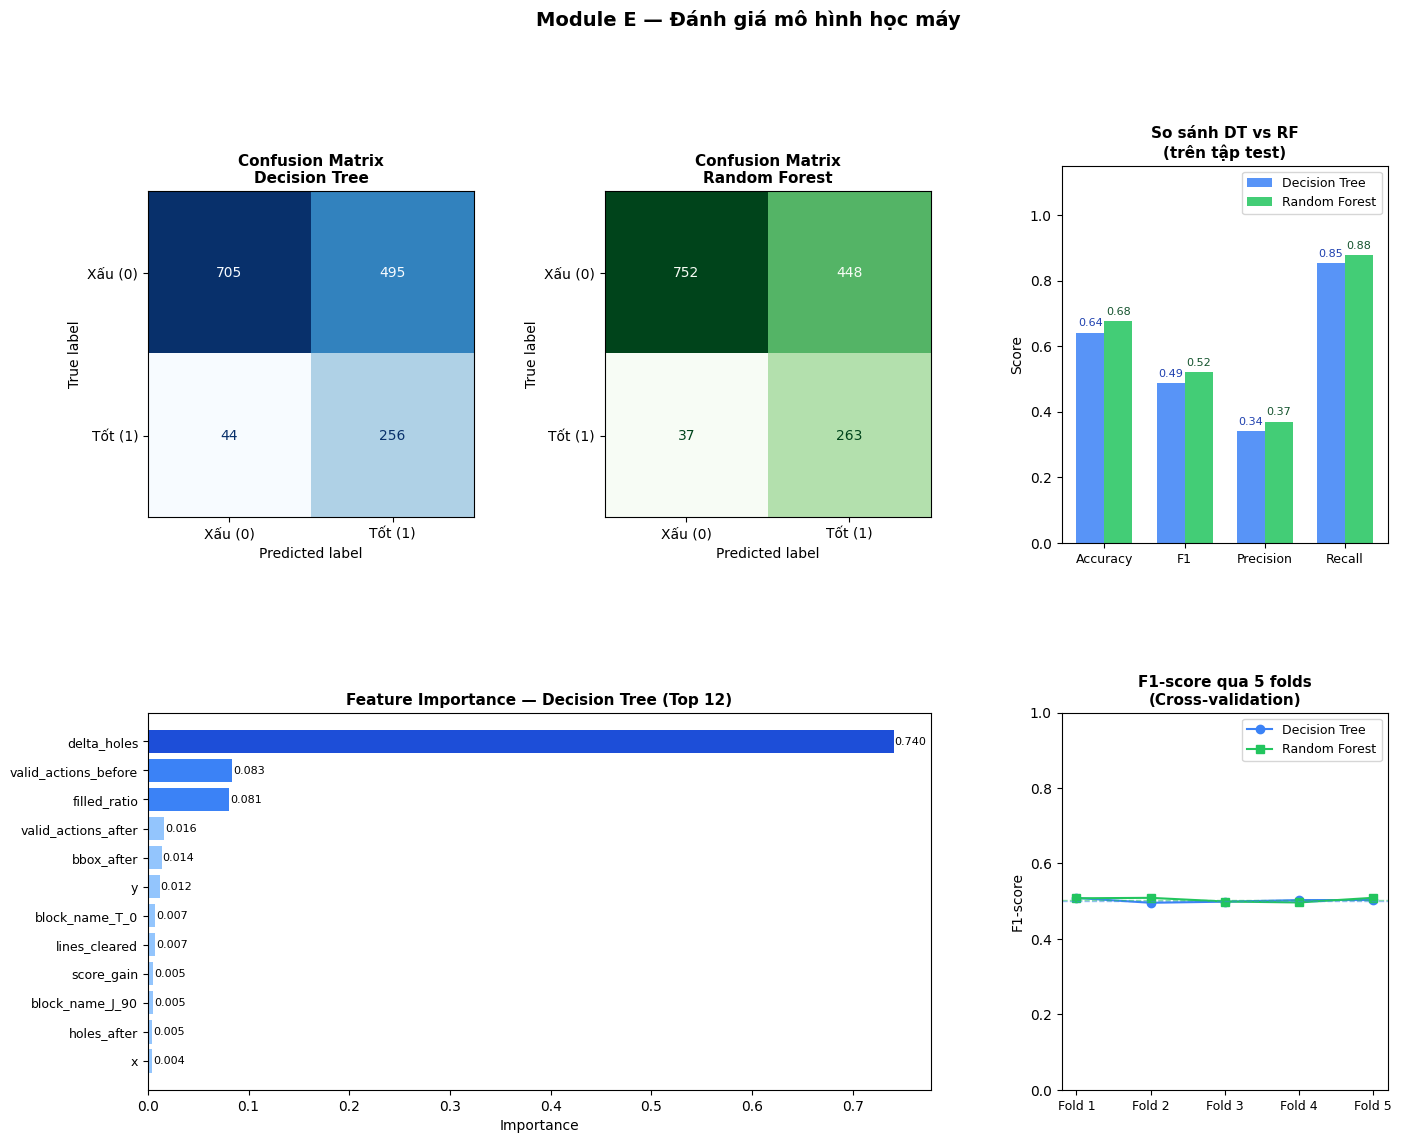

Biểu đồ đã lưu: module_e_evaluation.png


In [ ]:
# ── Biểu đồ so sánh đầy đủ ──────────────────────────────────────────────
fig = plt.figure(figsize=(16, 12))
gs = gridspec.GridSpec(2, 3, figure=fig, hspace=0.45, wspace=0.4)

# --- 1. Confusion Matrix: Decision Tree ---
ax1 = fig.add_subplot(gs[0, 0])
cm_dt = confusion_matrix(y_test, y_pred_dt)
disp_dt = ConfusionMatrixDisplay(cm_dt, display_labels=["Xấu (0)", "Tốt (1)"])
disp_dt.plot(ax=ax1, colorbar=False, cmap="Blues")
ax1.set_title("Confusion Matrix\nDecision Tree", fontsize=11, fontweight="bold")

# --- 2. Confusion Matrix: Random Forest ---
ax2 = fig.add_subplot(gs[0, 1])
cm_rf = confusion_matrix(y_test, y_pred_rf)
disp_rf = ConfusionMatrixDisplay(cm_rf, display_labels=["Xấu (0)", "Tốt (1)"])
disp_rf.plot(ax=ax2, colorbar=False, cmap="Greens")
ax2.set_title("Confusion Matrix\nRandom Forest", fontsize=11, fontweight="bold")

# --- 3. So sánh DT vs RF (bar chart) ---
ax3 = fig.add_subplot(gs[0, 2])
metrics_labels = ["Accuracy", "F1", "Precision", "Recall"]
dt_scores = [
    accuracy_score(y_test, y_pred_dt),
    f1_score(y_test, y_pred_dt),
    *[float(v) for v in classification_report(y_test, y_pred_dt, output_dict=True)["1"].values()][:2]
]
rf_scores = [
    accuracy_score(y_test, y_pred_rf),
    f1_score(y_test, y_pred_rf),
    *[float(v) for v in classification_report(y_test, y_pred_rf, output_dict=True)["1"].values()][:2]
]
x_pos = np.arange(len(metrics_labels))
w = 0.35
bars1 = ax3.bar(x_pos - w/2, dt_scores, w, label="Decision Tree", color="#3b82f6", alpha=0.85)
bars2 = ax3.bar(x_pos + w/2, rf_scores, w, label="Random Forest", color="#22c55e", alpha=0.85)
ax3.set_xticks(x_pos)
ax3.set_xticklabels(metrics_labels, fontsize=9)
ax3.set_ylim(0, 1.15)
ax3.set_title("So sánh DT vs RF\n(trên tập test)", fontsize=11, fontweight="bold")
ax3.legend(fontsize=9)
ax3.set_ylabel("Score")
for bar in bars1:
    ax3.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.02,
             f"{bar.get_height():.2f}", ha="center", fontsize=8, color="#1e40af")
for bar in bars2:
    ax3.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.02,
             f"{bar.get_height():.2f}", ha="center", fontsize=8, color="#14532d")

# --- 4. Feature Importance (Decision Tree, top 12) ---
ax4 = fig.add_subplot(gs[1, :2])
dt_importance = pd.DataFrame({
    "feature": feature_columns,
    "importance": dt_model.feature_importances_
}).sort_values("importance", ascending=True).tail(12)

colors_dt = ["#93c5fd" if imp < 0.05 else "#3b82f6" if imp < 0.1 else "#1d4ed8"
             for imp in dt_importance["importance"]]
ax4.barh(dt_importance["feature"], dt_importance["importance"], color=colors_dt)
ax4.set_title("Feature Importance — Decision Tree (Top 12)", fontsize=11, fontweight="bold")
ax4.set_xlabel("Importance")
ax4.tick_params(axis="y", labelsize=9)
for i, (_, row) in enumerate(dt_importance.iterrows()):
    ax4.text(row["importance"] + 0.001, i, f"{row['importance']:.3f}", va="center", fontsize=8)

# --- 5. Cross-val F1 per fold ---
ax5 = fig.add_subplot(gs[1, 2])
folds = [f"Fold {i+1}" for i in range(5)]
ax5.plot(folds, cv_dt["test_f1"], "o-", label="Decision Tree", color="#3b82f6")
ax5.plot(folds, cv_rf["test_f1"], "s-", label="Random Forest", color="#22c55e")
ax5.axhline(cv_dt["test_f1"].mean(), linestyle="--", color="#3b82f6", alpha=0.5, linewidth=1)
ax5.axhline(cv_rf["test_f1"].mean(), linestyle="--", color="#22c55e", alpha=0.5, linewidth=1)
ax5.set_title("F1-score qua 5 folds\n(Cross-validation)", fontsize=11, fontweight="bold")
ax5.set_ylabel("F1-score")
ax5.set_ylim(0, 1)
ax5.legend(fontsize=9)
ax5.tick_params(axis="x", labelsize=9)

plt.suptitle("Module E — Đánh giá mô hình học máy", fontsize=14, fontweight="bold", y=1.01)
plt.savefig("module_e_evaluation.png", dpi=120, bbox_inches="tight")
plt.show()
print("Biểu đồ đã lưu: module_e_evaluation.png")


In [ ]:
# ── Feature importance chi tiết ─────────────────────────────────────────
print("=" * 50)
print("TOP 10 FEATURES — Decision Tree")
print("=" * 50)
dt_imp_df = pd.DataFrame({
    "Đặc trưng": feature_columns,
    "Importance": dt_model.feature_importances_
}).sort_values("Importance", ascending=False)
print(dt_imp_df.head(10).to_string(index=False))

print()
print("=" * 50)
print("TOP 10 FEATURES — Random Forest")
print("=" * 50)
rf_imp_df = pd.DataFrame({
    "Đặc trưng": feature_columns,
    "Importance": rf_model.feature_importances_
}).sort_values("Importance", ascending=False)
print(rf_imp_df.head(10).to_string(index=False))

print()
print("=" * 50)
print("LUẬT DECISION TREE (3 mức đầu)")
print("=" * 50)
tree_rules = export_text(dt_model, feature_names=list(X.columns), max_depth=3)
print(tree_rules)


TOP 10 FEATURES — Decision Tree
           Đặc trưng  Importance
         delta_holes    0.740496
valid_actions_before    0.083330
        filled_ratio    0.081017
 valid_actions_after    0.016053
          bbox_after    0.013744
                   y    0.011676
      block_name_T_0    0.007284
       lines_cleared    0.007026
          score_gain    0.005166
     block_name_J_90    0.004913

TOP 10 FEATURES — Random Forest
           Đặc trưng  Importance
         delta_holes    0.459151
         holes_after    0.109513
          score_gain    0.054116
valid_actions_before    0.048842
 valid_actions_after    0.043978
       lines_cleared    0.038498
        holes_before    0.036435
        filled_ratio    0.026924
          delta_area    0.024414
         bbox_before    0.021827

LUẬT DECISION TREE (3 mức đầu)
|--- delta_holes <= 0.50
|   |--- filled_ratio <= 0.22
|   |   |--- valid_actions_after <= 46.50
|   |   |   |--- bbox_after <= 45.00
|   |   |   |   |--- truncated branch of de

In [ ]:
# ── Lưu model ra file (không cần train lại lần sau) ─────────────────────
MODEL_PATH = "blockblast_model.pkl"

# Lưu cả hai model + feature_columns vào một dict
save_data = {
    "dt_model": dt_model,
    "rf_model": rf_model,
    "best_model": best_model,
    "best_model_name": best_model_name,
    "feature_columns": feature_columns,
}
joblib.dump(save_data, MODEL_PATH)
file_size = os.path.getsize(MODEL_PATH) / 1024
print(f"Model đã lưu: {MODEL_PATH} ({file_size:.1f} KB)")

# ── Cách tải lại (chạy cell này thay cho toàn bộ Module D+E nếu đã có file) ─
print()
print("Cách tải lại model đã lưu (không cần train lại):")
print("  loaded = joblib.load('blockblast_model.pkl')")
print("  best_model = loaded['best_model']")
print("  feature_columns = loaded['feature_columns']")


Model đã lưu: blockblast_model.pkl (1069.2 KB)

Cách tải lại model đã lưu (không cần train lại):
  loaded = joblib.load('blockblast_model.pkl')
  best_model = loaded['best_model']
  feature_columns = loaded['feature_columns']


In [ ]:
# ── Hàm hỗ trợ: chuẩn bị feature cho 1 action ──────────────────────────
def prepare_action_row_for_model(state, action, feature_columns):
    """
    Trích xuất đặc trưng của 1 (state, action) và chuẩn hóa
    thành DataFrame row tương thích với feature_columns của model.
    """
    feats = extract_action_features(state, action)
    if feats is None:
        return None

    row = pd.DataFrame([feats])[BASE_FEATURE_COLUMNS]
    row = pd.get_dummies(row, columns=["block_name"], dtype=int)
    row = row.reindex(columns=feature_columns, fill_value=0)

    return row


def rank_actions_with_model(state, model, feature_columns, top_k=None):
    """
    Cho mỗi action hợp lệ: dự đoán P(label=1) bằng model,
    xếp hạng từ cao xuống thấp.

    Returns: list of (p_good, action) đã sort theo p_good giảm dần
    """
    actions = state.get_valid_actions()
    scored_actions = []

    for action in actions:
        row = prepare_action_row_for_model(state, action, feature_columns)
        if row is None:
            continue

        # predict_proba trả về [P(label=0), P(label=1)]
        p_good = model.predict_proba(row)[0][1]
        scored_actions.append((p_good, action))

    scored_actions.sort(key=lambda x: x[0], reverse=True)

    if top_k is not None:
        scored_actions = scored_actions[:top_k]

    return scored_actions

print("rank_actions_with_model: OK")


rank_actions_with_model: OK


In [ ]:
# ── BFS tích hợp ML ─────────────────────────────────────────────────────
def best_first_search_ml(
    initial_state,
    model,
    feature_columns,
    max_expansions=5000,
    w1=4, w2=2, w3=6, K=8,
    remaining_weight=5,
    ml_beta=3.0,
    action_top_k=None
):
    """
    Best-first Search với ML-guided priority.

    priority = evaluate_node(n)   - ml_beta * P(good | action)
             = [g(n) + λ*|blocks_remaining|]  - ml_beta * p_good

    Node có p_good cao → priority thấp hơn → được khám phá sớm hơn.

    Args:
        ml_beta: trọng số ảnh hưởng của ML (lớn hơn → tin ML hơn)
        action_top_k: chỉ xét top-k action theo ML (None = xét tất cả)
    """
    from itertools import count as _count

    root = Node(initial_state)
    root.priority = evaluate_node(root, remaining_weight=remaining_weight)

    frontier = []
    counter = _count()
    heapq.heappush(frontier, (root.priority, next(counter), root))

    best_seen_score = {initial_state.key(): initial_state.current_score}
    best_terminal = None
    best_partial = root
    expansions = 0

    while frontier and expansions < max_expansions:
        _, _, node = heapq.heappop(frontier)
        state = node.state
        key = state.key()

        if state.current_score < best_seen_score.get(key, -1):
            continue

        # Cập nhật best partial
        if state.current_score > best_partial.state.current_score:
            best_partial = node
        elif state.current_score == best_partial.state.current_score:
            if len(state.available_blocks) < len(best_partial.state.available_blocks):
                best_partial = node

        if state.is_terminal():
            if best_terminal is None or state.current_score > best_terminal.state.current_score:
                best_terminal = node
            continue

        expansions += 1

        # ML xếp hạng action
        ranked_actions = rank_actions_with_model(
            state, model=model,
            feature_columns=feature_columns,
            top_k=action_top_k
        )

        for p_good, action in ranked_actions:
            child_state = state.place_block(*action)
            if child_state is None:
                continue

            child_key = child_state.key()
            if child_state.current_score <= best_seen_score.get(child_key, -1):
                continue

            step_cost = transition_cost(state, action, child_state, w1=w1, w2=w2, w3=w3, K=K)
            child = Node(
                state=child_state,
                parent=node,
                action=action,
                path_cost=node.path_cost + step_cost
            )

            base_eval = evaluate_node(child, remaining_weight=remaining_weight)
            # ML ảnh hưởng priority: p_good cao → priority giảm → ưu tiên cao hơn
            child.priority = base_eval - ml_beta * p_good

            best_seen_score[child_key] = child_state.current_score
            heapq.heappush(frontier, (child.priority, next(counter), child))

    if best_terminal is not None:
        return best_terminal, expansions, True
    return best_partial, expansions, False

print("best_first_search_ml: OK")


best_first_search_ml: OK


## Demo — So sánh BFS thuần vs BFS + Decision Tree vs BFS + Random Forest

Chạy cả 3 chiến lược trên cùng 1 trạng thái. So sánh:
- **Điểm** cuối cùng đạt được
- **Số node** đã mở rộng (ít hơn = hiệu quả hơn)
- **Tìm thấy terminal** (đặt hết block) chưa


In [ ]:
# ── Setup trạng thái demo ────────────────────────────────────────────────
initial_board = np.zeros((8, 8), dtype=int)
available_blocks = ["O", "I_0", "T_180", "L_90"]

initial_state = State(
    board=initial_board,
    available_blocks=available_blocks,
    current_score=0
)

print(f"Trạng thái demo: {len(available_blocks)} khối cần đặt trên bàn 8×8 trống")
print(f"Khối: {available_blocks}\n")

# ── BFS thuần ────────────────────────────────────────────────────────────────
print("=" * 55)
print("1. BFS THUẦN (Module A + B + C)")
print("=" * 55)
import time

t0 = time.time()
base_result = best_first_search(
    initial_state, max_expansions=1000,
    w1=4, w2=2, w3=6, K=8, remaining_weight=5
)
t1 = time.time()
print_solution(base_result)
print(f"Thời gian: {t1-t0:.2f}s")

# ── BFS + Decision Tree ───────────────────────────────────────────────────────
print("\n" + "=" * 55)
print("2. BFS + DECISION TREE (Module A+B+C+D+E)")
print("=" * 55)

t0 = time.time()
dt_result = best_first_search_ml(
    initial_state, model=dt_model, feature_columns=feature_columns,
    max_expansions=1000, w1=4, w2=2, w3=6, K=8, remaining_weight=5, ml_beta=3.0
)
t1 = time.time()
print_solution(dt_result)
print(f"Thời gian: {t1-t0:.2f}s")

# ── Bảng tổng kết ────────────────────────────────────────────────────────────
print("\n" + "=" * 55)
print("BẢNG TỔNG KẾT SO SÁNH")
print("=" * 55)
results = [
    ("BFS thuần", base_result),
    ("BFS + DT", dt_result),
]
print(f"{'Phương pháp':<18} {'Điểm':>6} {'Node mở':>10} {'Terminal':>10}")
print("-" * 48)
for name, (node, expansions, terminal) in results:
    score = node.state.current_score if node else 0
    print(f"{name:<18} {score:>6} {expansions:>10} {str(terminal):>10}")


Trạng thái demo: 4 khối cần đặt trên bàn 8×8 trống
Khối: ['O', 'I_0', 'T_180', 'L_90']

1. BFS THUẦN (Module A + B + C)
Expanded nodes: 1000
Terminal found: True
Best score: 8
Placed blocks: 4
Remaining blocks: []

Action sequence:
  Step 1: place I_0 at (2, 0)
  Step 2: place T_180 at (2, 4)
  Step 3: place L_90 at (0, 6)
  Step 4: place O at (1, 5)

Final board:
[[0 0 0 0 0 0 1 1]
 [0 0 0 0 0 1 1 1]
 [0 0 0 0 0 1 1 0]
 [0 0 0 0 0 1 0 0]
 [0 0 0 0 0 0 0 0]
 [0 0 0 0 0 0 0 0]
 [0 0 0 0 0 0 0 0]
 [0 0 0 0 0 0 0 0]]
Thời gian: 15.38s

2. BFS + DECISION TREE (Module A+B+C+D+E)
Expanded nodes: 1000
Terminal found: True
Best score: 8
Placed blocks: 4
Remaining blocks: []

Action sequence:
  Step 1: place I_0 at (2, 4)
  Step 2: place O at (1, 2)
  Step 3: place L_90 at (2, 0)
  Step 4: place T_180 at (2, 1)

Final board:
[[0 0 0 0 0 0 0 0]
 [0 0 1 1 0 0 0 0]
 [0 1 1 1 0 0 0 0]
 [0 1 1 0 0 0 0 0]
 [0 1 0 0 0 0 0 0]
 [0 0 0 0 0 0 0 0]
 [0 0 0 0 0 0 0 0]
 [0 0 0 0 0 0 0 0]]
Thời gian: 385.03s


## Mô phỏng — Chơi nhiều lượt liên tiếp

Mô phỏng 3 lượt chơi. Bàn cờ giữ lại sau mỗi lượt.

In [ ]:
turns_blocks = [
    ['O', 'I_0', 'T_180', 'L_90'],
    ['S_0', 'Z_90', 'O', 'J_180'],
    ['T_0', 'I_90', 'L_0', 'O']
]

current_board = np.zeros((8, 8), dtype=int)
total_score = 0

MAX_EXPANSIONS = 1500
W1, W2, W3, K = 4, 2, 6, 8
REMAINING_WEIGHT = 5

game_history = []
turn_summaries = []

for turn_idx, blocks in enumerate(turns_blocks, start=1):
    initial_state = State(
        board=current_board,
        available_blocks=blocks,
        current_score=0
    )

    result = best_first_search_ml(
        initial_state,
        model=best_model,
        feature_columns=feature_columns,
        max_expansions=MAX_EXPANSIONS,
        w1=W1,
        w2=W2,
        w3=W3,
        K=K,
        remaining_weight=REMAINING_WEIGHT,
        ml_beta=3.0
    )

    best_node, expansions, found_terminal = result

    if best_node is None:
        print(f"Turn {turn_idx}: no solution found.")
        break

    node_chain = reconstruct_node_chain(best_node)

    game_history.append({
        "turn": turn_idx,
        "step_in_turn": 0,
        "action": None,
        "board": np.copy(node_chain[0].state.board),
        "turn_score": 0,
        "total_score": total_score,
        "remaining_blocks": list(node_chain[0].state.available_blocks)
    })

    for step_idx, node in enumerate(node_chain[1:], start=1):
        turn_score_now = node.state.current_score

        game_history.append({
            "turn": turn_idx,
            "step_in_turn": step_idx,
            "action": node.action,
            "board": np.copy(node.state.board),
            "turn_score": turn_score_now,
            "total_score": total_score + turn_score_now,
            "remaining_blocks": list(node.state.available_blocks)
        })

    turn_summaries.append({
        "turn": turn_idx,
        "expanded_nodes": expansions,
        "found_terminal": found_terminal,
        "turn_score": best_node.state.current_score,
        "num_actions": len(node_chain) - 1,
        "actions": [node.action for node in node_chain[1:]]
    })

    current_board = np.copy(best_node.state.board)
    total_score += best_node.state.current_score

    if not found_terminal:
        print(f"Turn {turn_idx}: search stopped before finishing all blocks.")
        break

print("=" * 60)
print("3-TURN GAME FINISHED  (model: Random Forest)")
print("=" * 60)
print("Final total score:", total_score)
print("Total snapshots stored:", len(game_history))

print("\nTURN SUMMARIES")
for summary in turn_summaries:
    print(f"\nTurn {summary['turn']}")
    print(f"  Expanded nodes : {summary['expanded_nodes']}")
    print(f"  Terminal found : {summary['found_terminal']}")
    print(f"  Turn score     : {summary['turn_score']}")
    print(f"  Number of moves: {summary['num_actions']}")
    for step, action in enumerate(summary["actions"], start=1):
        print(f"    Step {step}: place {action[0]} at ({action[1]}, {action[2]})")

3-TURN GAME FINISHED  (model: Random Forest)
Final total score: 40
Total snapshots stored: 15

TURN SUMMARIES

Turn 1
  Expanded nodes : 1500
  Terminal found : True
  Turn score     : 8
  Number of moves: 4
    Step 1: place I_0 at (4, 4)
    Step 2: place O at (3, 2)
    Step 3: place L_90 at (4, 0)
    Step 4: place T_180 at (4, 1)

Turn 2
  Expanded nodes : 1500
  Terminal found : True
  Turn score     : 16
  Number of moves: 4
    Step 1: place Z_90 at (5, 2)
    Step 2: place J_180 at (2, 2)
    Step 3: place O at (0, 2)
    Step 4: place S_0 at (6, 3)

Turn 3
  Expanded nodes : 1500
  Terminal found : True
  Turn score     : 16
  Number of moves: 4
    Step 1: place T_0 at (6, 1)
    Step 2: place I_90 at (0, 1)
    Step 3: place O at (4, 4)
    Step 4: place L_0 at (0, 2)


## Visualization — Xem lại từng bước đặt block

Dùng thanh trượt để xem từng snapshot.

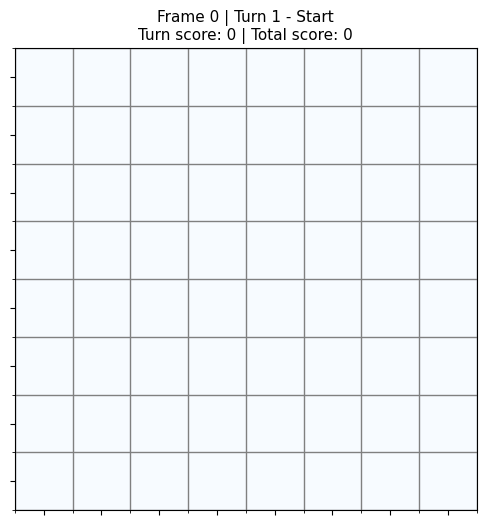

<function __main__.show_snapshot(frame_idx)>

In [ ]:
import matplotlib.pyplot as plt
from ipywidgets import interact, IntSlider

def show_snapshot(frame_idx):
    snapshot = game_history[frame_idx]
    board = snapshot["board"]

    fig, ax = plt.subplots(figsize=(6, 6))
    ax.imshow(board, cmap="Blues", vmin=0, vmax=1)

    H, W = board.shape
    ax.set_xticks(np.arange(-0.5, W, 1), minor=True)
    ax.set_yticks(np.arange(-0.5, H, 1), minor=True)
    ax.grid(which="minor", color="gray", linestyle="-", linewidth=1)

    ax.set_xticks(range(W))
    ax.set_yticks(range(H))
    ax.set_xticklabels([])
    ax.set_yticklabels([])

    action = snapshot["action"]
    if action is None:
        title = (
            f"Frame {frame_idx} | Turn {snapshot['turn']} - Start\n"
            f"Turn score: {snapshot['turn_score']} | Total score: {snapshot['total_score']}"
        )
    else:
        title = (
            f"Frame {frame_idx} | Turn {snapshot['turn']} - Step {snapshot['step_in_turn']}\n"
            f"Action: {action[0]} at ({action[1]}, {action[2]})\n"
            f"Turn score: {snapshot['turn_score']} | Total score: {snapshot['total_score']}"
        )

    ax.set_title(title, fontsize=11)
    plt.show()

interact(
    show_snapshot,
    frame_idx=IntSlider(min=0, max=len(game_history)-1, step=1, value=0)
)